In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
TRAIN_PATH = "../dataset/emnist/emnist-balanced-train.csv"
TEST_PATH = "../dataset/emnist/emnist-balanced-test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train classes:", train_df.iloc[:, 0].nunique())
print("Test classes :", test_df.iloc[:, 0].nunique())

Train shape: (112799, 785)
Test shape : (18799, 785)
Train classes: 47
Test classes : 47


In [3]:
train_df = train_df.rename(columns={train_df.columns[0]: "label"})
test_df = test_df.rename(columns={test_df.columns[0]: "label"})

X_train = train_df.drop("label", axis=1).to_numpy(dtype="float32") / 255.0
y_train = train_df["label"].to_numpy(dtype="int64")

X_test = test_df.drop("label", axis=1).to_numpy(dtype="float32") / 255.0
y_test = test_df["label"].to_numpy(dtype="int64")

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(112799, 784) (112799,)
(18799, 784) (18799,)


In [4]:
# Convert 784 pixels -> 28x28.
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

# IMPORTANT:
# EMNIST CSV images need a transpose to appear upright.
X_train_img = np.transpose(X_train_img, (0, 2, 1))
X_test_img = np.transpose(X_test_img, (0, 2, 1))

# CNN expects a channel dimension.
X_train_cnn = X_train_img[..., np.newaxis]
X_test_cnn = X_test_img[..., np.newaxis]

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape :", X_test_cnn.shape)

CNN train shape: (112799, 28, 28, 1)
CNN test shape : (18799, 28, 28, 1)


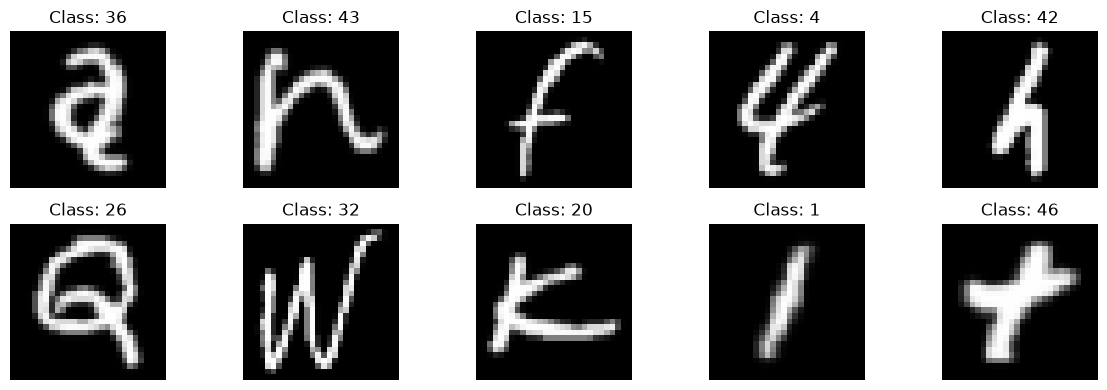

In [5]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_img[i], cmap="gray")
    plt.title(f"Class: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Mapping used by the backend.
class_mapping = {
    0:"0", 1:"1", 2:"2", 3:"3", 4:"4", 5:"5", 6:"6", 7:"7", 8:"8", 9:"9",
    10:"A", 11:"B", 12:"C", 13:"D", 14:"E", 15:"F", 16:"G", 17:"H",
    18:"I", 19:"J", 20:"K", 21:"L", 22:"M", 23:"N", 24:"O", 25:"P",
    26:"Q", 27:"R", 28:"S", 29:"T", 30:"U", 31:"V", 32:"W", 33:"X",
    34:"Y", 35:"Z", 36:"a", 37:"b", 38:"d", 39:"e", 40:"f", 41:"g",
    42:"h", 43:"n", 44:"q", 45:"r", 46:"t"
}

print(class_mapping[10], class_mapping[20], class_mapping[22], class_mapping[46])

A K M t


In [7]:
# Keep the official EMNIST test set untouched.
# Validation is taken only from the training set.

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_cnn,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Train:", X_tr.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_cnn.shape)

Train: (101519, 28, 28, 1)
Validation: (11280, 28, 28, 1)
Test: (18799, 28, 28, 1)


In [8]:
cnn = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(47, activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

D:\HandWriteAI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 47)                  │           6,063 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 230,191 (899.18 KB)

 Trainable params: 229,999 (898.43 KB)

 Non-trainable params: 192 (768.00 B)

In [9]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../model/emnist_cnn_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = cnn.fit(
    X_tr,
    y_tr,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 103s 123ms/step - accuracy: 0.6946 - loss: 1.0211 - val_accuracy: 0.8380 - val_loss: 0.4719
Epoch 2/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.8168 - loss: 0.5572 - val_accuracy: 0.8524 - val_loss: 0.4097
Epoch 3/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 92s 116ms/step - accuracy: 0.8375 - loss: 0.4787 - val_accuracy: 0.8668 - val_loss: 0.3840
Epoch 4/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 92s 115ms/step - accuracy: 0.8498 - loss: 0.4346 - val_accuracy: 0.8648 - val_loss: 0.3782
Epoch 5/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 88s 111ms/step - accuracy: 0.8577 - loss: 0.4070 - val_accuracy: 0.8679 - val_loss: 0.3733
Epoch 6/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 99s 124ms/step - accuracy: 0.8639 - loss: 0.3847 - val_accuracy: 0.8681 - val_loss: 0.3647
Epoch 7/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.8679 - loss: 0.3673 - val_accuracy: 0.8750 - val_loss: 0.3598
Epoch 8/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 144s 120ms/step - accuracy: 0.8731 - loss:

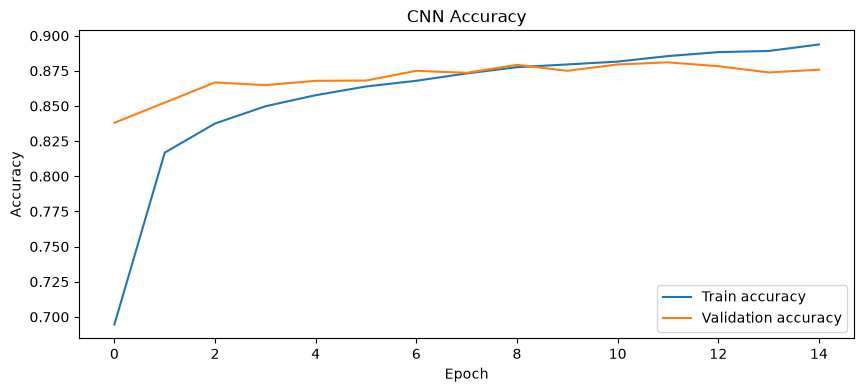

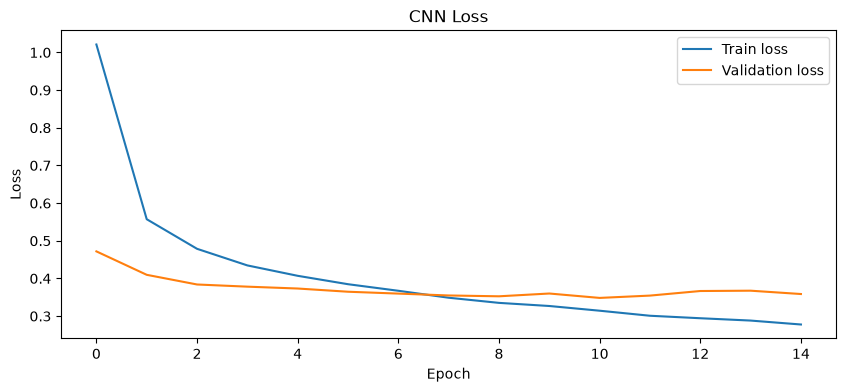

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.show()

In [11]:
test_loss, test_accuracy = cnn.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8774 - loss: 0.3784
Test loss: 0.3784
Test accuracy: 0.8774
Test accuracy: 87.74%


In [12]:
# Detailed class-wise metrics
y_prob = cnn.predict(X_test_cnn, batch_size=256, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[class_mapping[i] for i in range(47)],
        digits=4,
        zero_division=0
    )
)

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step
Macro F1: 0.8763776033207205
Weighted F1: 0.8763878445113873
              precision    recall  f1-score   support

           0     0.6111    0.8250    0.7021       400
           1     0.5678    0.6800    0.6189       400
           2     0.9121    0.8825    0.8971       400
           3     0.9874    0.9800    0.9837       400
           4     0.9409    0.9150    0.9278       400
           5     0.9575    0.8450    0.8977       400
           6     0.8931    0.9400    0.9160       400
           7     0.9751    0.9775    0.9763       400
           8     0.9327    0.9350    0.9338       400
           9     0.6874    0.7750    0.7286       400
           A     0.9602    0.9650    0.9626       400
           B     0.9578    0.9650    0.9614       400
           C     0.9618    0.9450    0.9533       400
           D     0.9308    0.9075    0.9190       400
           E     0.9849    0.9775    0.9812       400
           F     0.7456    0.5275 

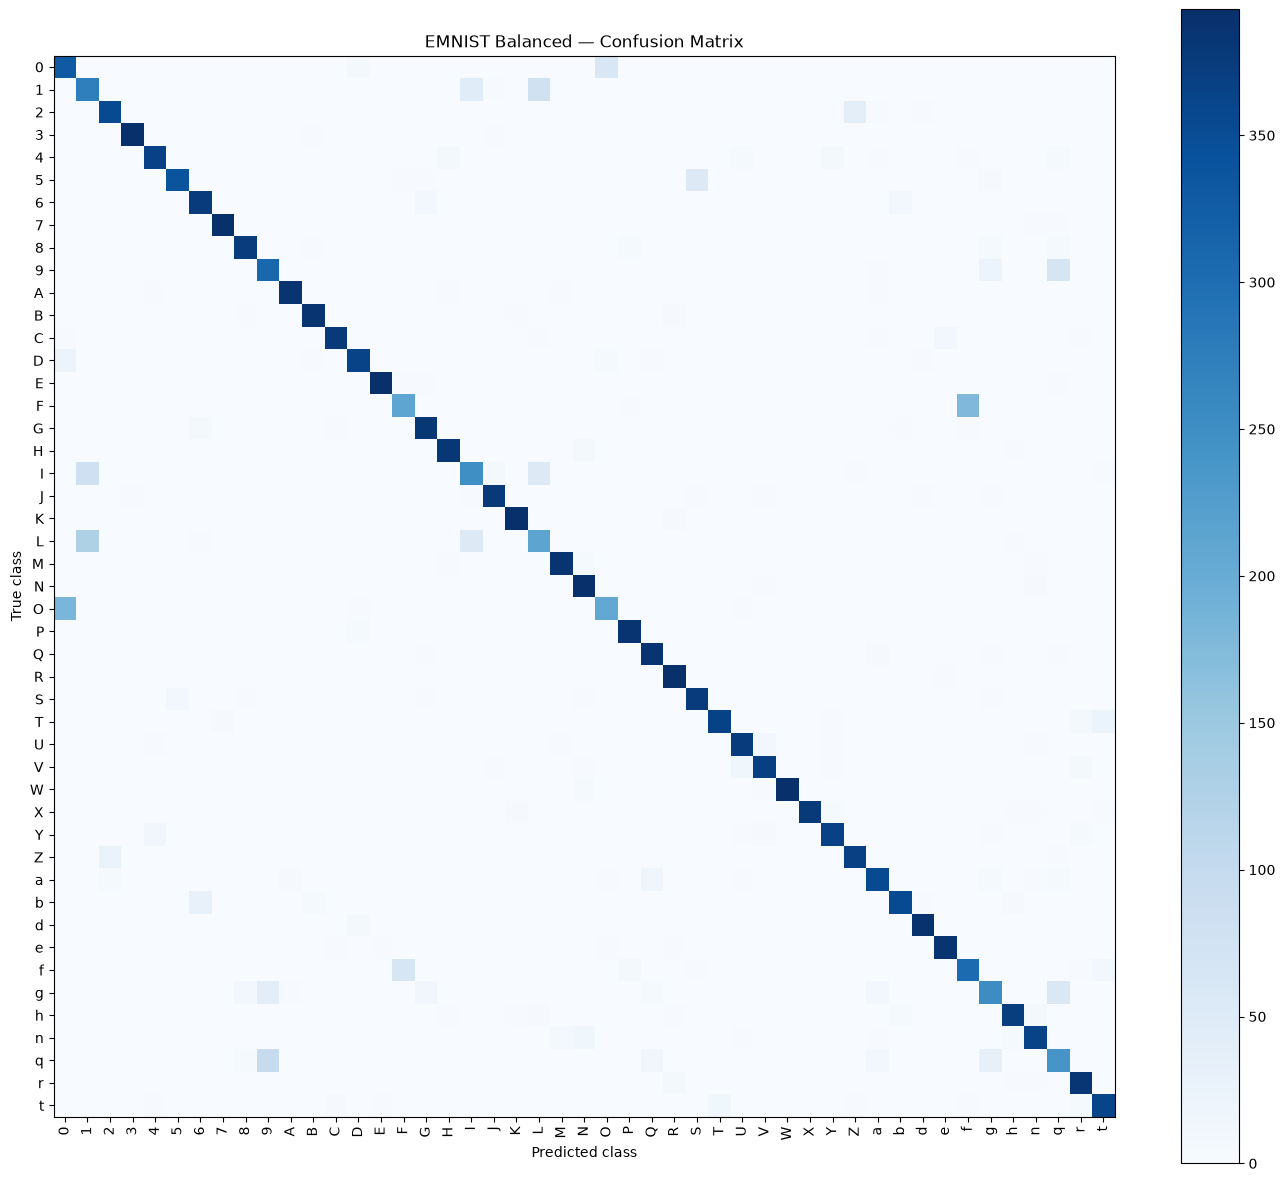

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("EMNIST Balanced — Confusion Matrix")
plt.xticks(range(47), [class_mapping[i] for i in range(47)], rotation=90)
plt.yticks(range(47), [class_mapping[i] for i in range(47)])
plt.tight_layout()
plt.show()

In [14]:
# Test a few known test images through exactly the same model input pipeline.

for i in range(10):
    p = cnn.predict(X_test_cnn[i:i+1], verbose=0)[0]
    pred_class = int(np.argmax(p))
    print(
        f"True: {y_test[i]} ({class_mapping[y_test[i]]}) | "
        f"Pred: {pred_class} ({class_mapping[pred_class]}) | "
        f"Confidence: {p[pred_class] * 100:.2f}%"
    )

True: 39 (e) | Pred: 39 (e) | Confidence: 100.00%
True: 9 (9) | Pred: 9 (9) | Confidence: 68.74%
True: 26 (Q) | Pred: 26 (Q) | Confidence: 99.81%
True: 44 (q) | Pred: 44 (q) | Confidence: 47.79%
True: 33 (X) | Pred: 33 (X) | Confidence: 100.00%
True: 14 (E) | Pred: 14 (E) | Confidence: 100.00%
True: 11 (B) | Pred: 27 (R) | Confidence: 82.21%
True: 3 (3) | Pred: 3 (3) | Confidence: 99.93%
True: 12 (C) | Pred: 12 (C) | Confidence: 97.19%
True: 16 (G) | Pred: 16 (G) | Confidence: 99.97%


In [16]:
import os

os.makedirs("../models", exist_ok=True)

cnn.save("../models/mnist_cnn.keras")

print("Saved:", os.path.abspath("../models/mnist_cnn.keras"))
print("Exists:", os.path.exists("../models/mnist_cnn.keras"))

Saved: D:\HandWriteAI\models\mnist_cnn.keras
Exists: True


In [17]:
import cv2
import numpy as np

# Test image
index = 0

sample = X_test_img[index]

true_class = int(y_test[index])

print("True class:", true_class)
print("True character:", class_mapping[true_class])


# X_test_img:
# white character on black background
#
# Backend expects:
# black character on white background
#
# Therefore invert it before saving.

sample_for_backend = (
    255 - (sample * 255)
).astype(np.uint8)


cv2.imwrite(
    "../test_backend.png",
    sample_for_backend
)

print("Saved:")
print("../test_backend.png")

True class: 39
True character: e
Saved:
../test_backend.png


In [18]:
from PIL import Image
import numpy as np

img = Image.open("../app/Backend/debug_processed.png").convert("L")

img_array = np.array(img)

img_array = img_array.astype("float32") / 255.0

img_array = img_array.reshape(1, 28, 28, 1)

print(img_array.shape)
print(img_array.min(), img_array.max())

(1, 28, 28, 1)
0.0 0.95686275


In [21]:
import json
import numpy as np

with open("../app/Backend/result.json", "r", encoding="utf-8") as f:
    class_mapping = json.load(f)

prediction = cnn.predict(img_array, verbose=0)[0]

top5_indices = np.argsort(prediction)[-5:][::-1]

for idx in top5_indices:
    print(
        "Class:", int(idx),
        "| Character:", class_mapping[str(int(idx))],
        "| Confidence:", round(float(prediction[idx]) * 100, 2), "%"
    )

Class: 46 | Character: t | Confidence: 64.09 %
Class: 40 | Character: f | Confidence: 13.46 %
Class: 15 | Character: F | Confidence: 8.86 %
Class: 29 | Character: T | Confidence: 7.62 %
Class: 35 | Character: Z | Confidence: 5.66 %


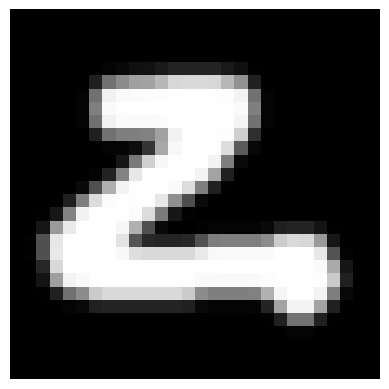

In [20]:
import matplotlib.pyplot as plt

idx = np.where(y_test == 35)[0][0]

plt.imshow(X_test_cnn[idx].squeeze(), cmap="gray")
plt.axis("off");

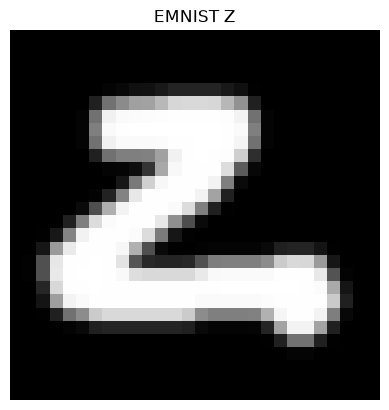

In [22]:
import matplotlib.pyplot as plt

idx = np.where(y_test == 35)[0][0]

plt.imshow(X_test_cnn[idx].squeeze(), cmap="gray")
plt.title("EMNIST Z")
plt.axis("off");

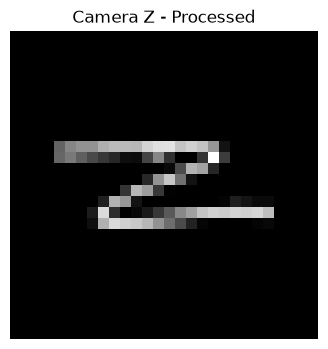

In [23]:
plt.figure(figsize=(4,4))
plt.imshow(img_array[0].squeeze(), cmap="gray")
plt.title("Camera Z - Processed")
plt.axis("off");

In [24]:
z_indices = np.where(y_test == 35)[0][:10]

for idx in z_indices:
    sample = X_test_cnn[idx:idx+1]

    pred = cnn.predict(sample, verbose=0)[0]

    predicted_class = np.argmax(pred)

    print(
        "True:",
        class_mapping[str(35)],
        "| Pred:",
        class_mapping[str(int(predicted_class))],
        "| Confidence:",
        round(float(pred[predicted_class]) * 100, 2)
    )

True: Z | Pred: Z | Confidence: 99.8
True: Z | Pred: Z | Confidence: 100.0
True: Z | Pred: Z | Confidence: 98.3
True: Z | Pred: Z | Confidence: 77.11
True: Z | Pred: Z | Confidence: 98.79
True: Z | Pred: Z | Confidence: 99.2
True: Z | Pred: Z | Confidence: 97.51
True: Z | Pred: Z | Confidence: 99.94
True: Z | Pred: Z | Confidence: 99.76
True: Z | Pred: Z | Confidence: 80.71


In [25]:
z_idx = np.where(y_test == 35)[0][0]

emnist_z = X_test_cnn[z_idx].squeeze()
camera_z = img_array[0].squeeze()

print("EMNIST Z:")
print("min:", emnist_z.min())
print("max:", emnist_z.max())
print("mean:", emnist_z.mean())
print("non-zero:", np.count_nonzero(emnist_z))

print("\nCamera Z:")
print("min:", camera_z.min())
print("max:", camera_z.max())
print("mean:", camera_z.mean())
print("non-zero:", np.count_nonzero(camera_z))

EMNIST Z:
min: 0.0
max: 1.0
mean: 0.2554522
non-zero: 322

Camera Z:
min: 0.0
max: 0.95686275
mean: 0.04441777
non-zero: 83


In [26]:
print("EMNIST Z non-zero:",
      np.count_nonzero(emnist_z))

print("Camera Z non-zero:",
      np.count_nonzero(camera_z))

EMNIST Z non-zero: 322
Camera Z non-zero: 83


Original:
Shape: (28, 28)
Min: 0
Max: 244
Mean: 11.326530612244898
Non-zero: 83

After dilation:
Shape: (28, 28)
Min: 0
Max: 244
Mean: 23.446428571428573
Non-zero: 132


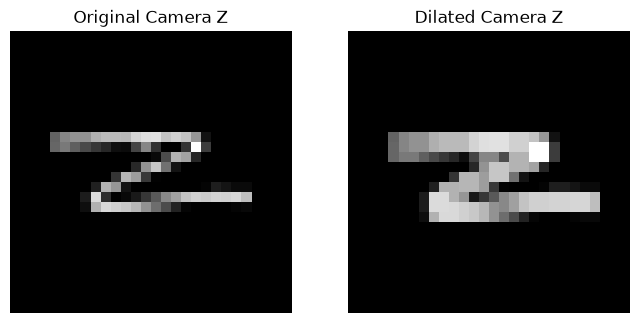

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the already processed Z image
img = cv2.imread("../app/Backend/debug_processed.png", cv2.IMREAD_GRAYSCALE)

print("Original:")
print("Shape:", img.shape)
print("Min:", img.min())
print("Max:", img.max())
print("Mean:", img.mean())
print("Non-zero:", np.count_nonzero(img))

# Small dilation to make strokes thicker
kernel = np.ones((2, 2), np.uint8)

dilated = cv2.dilate(
    img,
    kernel,
    iterations=1
)

print("\nAfter dilation:")
print("Shape:", dilated.shape)
print("Min:", dilated.min())
print("Max:", dilated.max())
print("Mean:", dilated.mean())
print("Non-zero:", np.count_nonzero(dilated))

# Display both
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Camera Z")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dilated, cmap="gray")
plt.title("Dilated Camera Z")
plt.axis("off")

plt.show()

In [28]:
# Normalize
dilated_input = dilated.astype("float32") / 255.0

# Add batch and channel dimensions
dilated_input = dilated_input.reshape(1, 28, 28, 1)

# Prediction
prediction = cnn.predict(dilated_input, verbose=0)[0]

top5_indices = np.argsort(prediction)[-5:][::-1]

print("\n===== DILATED Z PREDICTION =====")

for idx in top5_indices:
    print(
        "Class:", int(idx),
        "| Character:", class_mapping[str(int(idx))],
        "| Confidence:", round(float(prediction[idx]) * 100, 2), "%"
    )


===== DILATED Z PREDICTION =====
Class: 46 | Character: t | Confidence: 39.54 %
Class: 40 | Character: f | Confidence: 27.91 %
Class: 35 | Character: Z | Confidence: 18.89 %
Class: 15 | Character: F | Confidence: 7.79 %
Class: 29 | Character: T | Confidence: 5.8 %


In [29]:
kernel = np.ones((2, 2), np.uint8)

dilated2 = cv2.dilate(
    img,
    kernel,
    iterations=2
)

print("===== DILATION ×2 =====")

print("Shape:", dilated2.shape)
print("Min:", dilated2.min())
print("Max:", dilated2.max())
print("Mean:", dilated2.mean())
print("Non-zero:", np.count_nonzero(dilated2))

# Prepare for CNN
dilated2_input = dilated2.astype("float32") / 255.0
dilated2_input = dilated2_input.reshape(1, 28, 28, 1)

prediction = cnn.predict(dilated2_input, verbose=0)[0]

top5_indices = np.argsort(prediction)[-5:][::-1]

print("\n===== DILATION ×2 PREDICTION =====")

for idx in top5_indices:
    print(
        "Class:", int(idx),
        "| Character:", class_mapping[str(int(idx))],
        "| Confidence:", round(float(prediction[idx]) * 100, 2), "%"
    )

===== DILATION ×2 =====
Shape: (28, 28)
Min: 0
Max: 244
Mean: 35.07015306122449
Non-zero: 175

===== DILATION ×2 PREDICTION =====
Class: 35 | Character: Z | Confidence: 71.42 %
Class: 46 | Character: t | Confidence: 21.27 %
Class: 29 | Character: T | Confidence: 5.14 %
Class: 2 | Character: 2 | Confidence: 0.71 %
Class: 39 | Character: e | Confidence: 0.69 %


In [30]:
kernel = np.ones((2, 2), np.uint8)

dilated2 = cv2.dilate(
    img,
    kernel,
    iterations=2
)

dilated2_input = dilated2.astype("float32") / 255.0
dilated2_input = dilated2_input.reshape(1, 28, 28, 1)

prediction = cnn.predict(dilated2_input, verbose=0)[0]

top5_indices = np.argsort(prediction)[-5:][::-1]

for idx in top5_indices:
    print(
        "Class:", int(idx),
        "| Character:", class_mapping[str(int(idx))],
        "| Confidence:", round(float(prediction[idx]) * 100, 2), "%"
    )

Class: 35 | Character: Z | Confidence: 71.42 %
Class: 46 | Character: t | Confidence: 21.27 %
Class: 29 | Character: T | Confidence: 5.14 %
Class: 2 | Character: 2 | Confidence: 0.71 %
Class: 39 | Character: e | Confidence: 0.69 %


In [39]:
image_path = r"D:\HandWriteAI\app\Backend\debug_processed.png"

img_original = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

print("Type:", type(img_original))
print("Loaded:", img_original is not None)

if img_original is not None:
    print("Shape:", img_original.shape)
    print("Dtype:", img_original.dtype)
    print("Min:", img_original.min())
    print("Max:", img_original.max())

Type: <class 'numpy.ndarray'>
Loaded: True
Shape: (28, 28)
Dtype: uint8
Min: 0
Max: 255


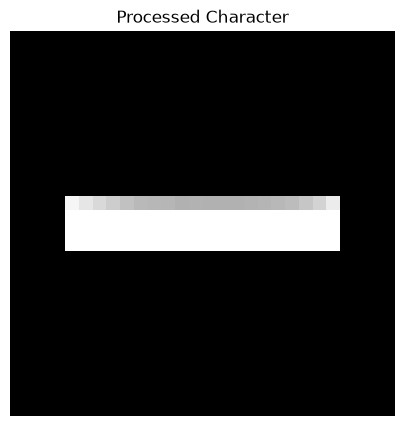

In [40]:
plt.figure(figsize=(5, 5))

plt.imshow(
    img_original,
    cmap="gray"
)

plt.title("Processed Character")
plt.axis("off")

plt.show()

In [41]:
_, binary = cv2.threshold(
    img_original,
    100,
    255,
    cv2.THRESH_BINARY_INV
)

print("Shape:", binary.shape)
print("Min:", binary.min())
print("Max:", binary.max())
print("Non-zero:", np.count_nonzero(binary))

Shape: (28, 28)
Min: 0
Max: 255
Non-zero: 704


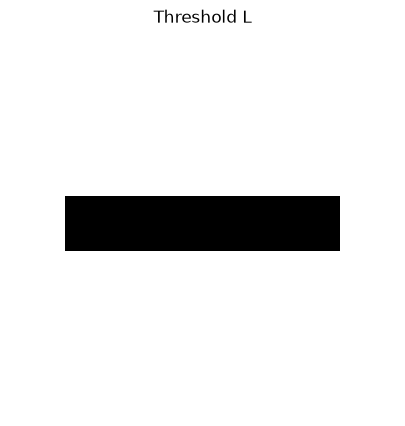

In [42]:
plt.figure(figsize=(5,5))

plt.imshow(binary, cmap="gray")

plt.title("Threshold L")
plt.axis("off")

plt.show()

In [45]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

Number of contours: 1


In [46]:
contours = sorted(
    contours,
    key=cv2.contourArea,
    reverse=True
)

character_contour = None

for contour in contours:

    x, y, w, h = cv2.boundingRect(contour)

    if w >= 10 and h >= 10:
        character_contour = contour
        break

if character_contour is None:
    raise ValueError("Character not detected")

x, y, w, h = cv2.boundingRect(character_contour)

print("Bounding box:")
print("x =", x)
print("y =", y)
print("width =", w)
print("height =", h)

Bounding box:
x = 0
y = 0
width = 28
height = 28


In [47]:
cropped = binary[y:y+h, x:x+w]

print("Cropped shape:", cropped.shape)

Cropped shape: (28, 28)


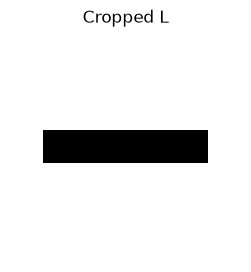

In [49]:
plt.figure(figsize=(6,3))

plt.imshow(cropped, cmap="gray")

plt.title("Cropped L")
plt.axis("off")

plt.show()

In [51]:
height, width = cropped.shape

scale = min(20 / width, 20 / height)

new_width = max(1, int(width * scale))
new_height = max(1, int(height * scale))

cropped_resized = cv2.resize(
    cropped,
    (new_width, new_height),
    interpolation=cv2.INTER_AREA
)

print("Original character size:", width, "x", height)
print("Resized character size :", new_width, "x", new_height)

Original character size: 28 x 28
Resized character size : 20 x 20


In [52]:
canvas = np.zeros(
    (28, 28),
    dtype=np.uint8
)

start_x = (28 - new_width) // 2
start_y = (28 - new_height) // 2

canvas[
    start_y:start_y + new_height,
    start_x:start_x + new_width
] = cropped_resized

print("Canvas shape:", canvas.shape)
print("Start position:", start_x, start_y)
print("Non-zero pixels:", np.count_nonzero(canvas))
print("Mean:", canvas.mean())
print("Max:", canvas.max())
print("Min:", canvas.min())

Canvas shape: (28, 28)
Start position: 4 4
Non-zero pixels: 372
Mean: 116.83673469387755
Max: 255
Min: 0


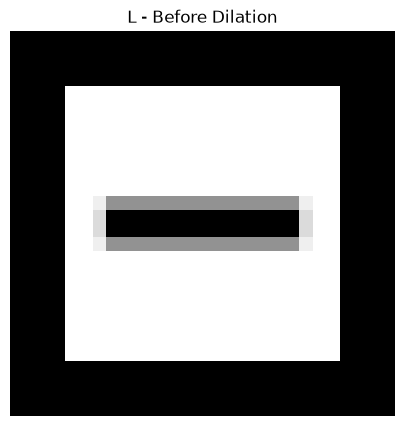

In [53]:
plt.figure(figsize=(5,5))

plt.imshow(canvas, cmap="gray")

plt.title("L - Before Dilation")
plt.axis("off")

plt.show()

In [54]:
kernel = np.ones(
    (2, 2),
    np.uint8
)

dilated2 = cv2.dilate(
    canvas,
    kernel,
    iterations=2
)

print("===== DILATION ×2 =====")

print("Shape:", dilated2.shape)
print("Min:", dilated2.min())
print("Max:", dilated2.max())
print("Mean:", dilated2.mean())
print("Non-zero:", np.count_nonzero(dilated2))

===== DILATION ×2 =====
Shape: (28, 28)
Min: 0
Max: 255
Mean: 154.00510204081633
Non-zero: 484


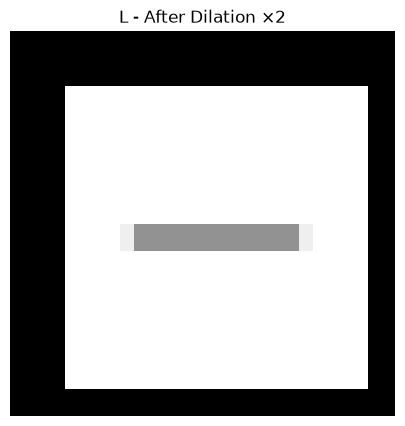

In [56]:
plt.figure(figsize=(5,5))

plt.imshow(dilated2, cmap="gray")

plt.title("L - After Dilation ×2")
plt.axis("off")

plt.show()

In [57]:
l_input = dilated2.astype("float32") / 255.0

l_input = l_input.reshape(
    1, 28, 28, 1
)

print("Input shape:", l_input.shape)
print("Min:", l_input.min())
print("Max:", l_input.max())

Input shape: (1, 28, 28, 1)
Min: 0.0
Max: 1.0


In [59]:
prediction = cnn.predict(
    l_input,
    verbose=0
)[0]

top5_indices = np.argsort(
    prediction
)[-5:][::-1]

print("===== L DILATION ×2 PREDICTION =====")

for idx in top5_indices:

    print(
        "Class:", int(idx),
        "| Character:", class_mapping[str(int(idx))],
        "| Confidence:",
        round(float(prediction[idx]) * 100, 2),
        "%"
    )

===== L DILATION ×2 PREDICTION =====
Class: 45 | Character: r | Confidence: 75.25 %
Class: 39 | Character: e | Confidence: 18.49 %
Class: 15 | Character: F | Confidence: 3.38 %
Class: 8 | Character: 8 | Confidence: 0.86 %
Class: 25 | Character: P | Confidence: 0.52 %


In [76]:
image_path = r"D:\l.jpeg"

img = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

print("Loaded:", img is not None)

if img is not None:
    print("Shape:", img.shape)
    print("Min:", img.min())
    print("Max:", img.max())
    print("Non-zero:", np.count_nonzero(img))

Loaded: True
Shape: (1280, 720)
Min: 21
Max: 211
Non-zero: 921600


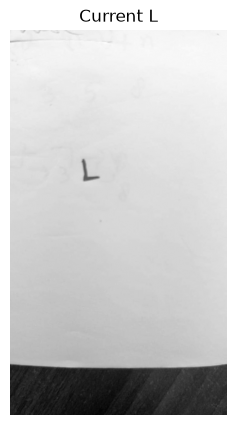

In [77]:
plt.figure(figsize=(5, 5))

plt.imshow(img, cmap="gray")

plt.title("Current L")
plt.axis("off")

plt.show()

In [78]:
_, binary = cv2.threshold(
    img,
    100,
    255,
    cv2.THRESH_BINARY_INV
)

print("Shape:", binary.shape)
print("Non-zero:", np.count_nonzero(binary))

Shape: (1280, 720)
Non-zero: 115171


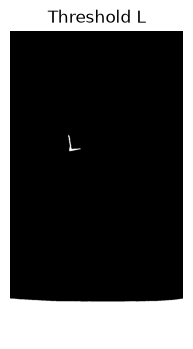

In [79]:
plt.figure(figsize=(6, 4))

plt.imshow(binary, cmap="gray")

plt.title("Threshold L")
plt.axis("off")

plt.show()

In [80]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contours = sorted(
    contours,
    key=cv2.contourArea,
    reverse=True
)

print("Contours:", len(contours))

Contours: 2


In [81]:
character_contour = None

for contour in contours:

    x, y, w, h = cv2.boundingRect(contour)

    if w >= 10 and h >= 10:
        character_contour = contour
        break

if character_contour is None:
    raise ValueError("L not detected")

x, y, w, h = cv2.boundingRect(character_contour)

print("Bounding box")
print("x:", x)
print("y:", y)
print("width:", w)
print("height:", h)

Bounding box
x: 0
y: 1111
width: 720
height: 169


In [82]:
cropped = binary[
    y:y+h,
    x:x+w
]

print("Cropped shape:", cropped.shape)

Cropped shape: (169, 720)


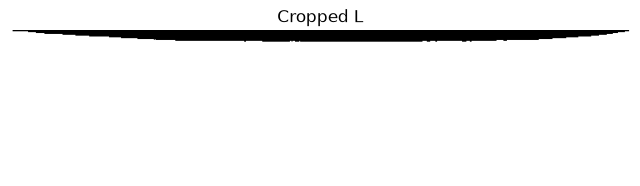

In [83]:
plt.figure(figsize=(8, 3))

plt.imshow(cropped, cmap="gray")

plt.title("Cropped L")
plt.axis("off")

plt.show()

In [84]:
target_height = 20

scale = target_height / h

new_height = target_height
new_width = max(
    1,
    int(w * scale)
)

print("Original:", w, "x", h)
print("New size:", new_width, "x", new_height)

Original: 720 x 169
New size: 85 x 20


In [85]:
resized = cv2.resize(
    cropped,
    (new_width, new_height),
    interpolation=cv2.INTER_AREA
)

print("Resized shape:", resized.shape)

Resized shape: (20, 85)


In [86]:
canvas_l = np.zeros(
    (28, 28),
    dtype=np.uint8
)

# If width is larger than 28, scale it down again
if new_width > 26:

    final_scale = 26 / new_width

    final_width = 26
    final_height = max(
        1,
        int(new_height * final_scale)
    )

    resized = cv2.resize(
        resized,
        (final_width, final_height),
        interpolation=cv2.INTER_AREA
    )

else:

    final_width = new_width
    final_height = new_height

print("Final character:", final_width, "x", final_height)

Final character: 26 x 6


In [87]:
start_x = (28 - final_width) // 2
start_y = (28 - final_height) // 2

canvas_l[
    start_y:start_y + final_height,
    start_x:start_x + final_width
] = resized

print("Canvas:", canvas_l.shape)
print("Start:", start_x, start_y)
print("Non-zero:", np.count_nonzero(canvas_l))
print("Mean:", canvas_l.mean())

Canvas: (28, 28)
Start: 1 11
Non-zero: 156
Mean: 47.764030612244895


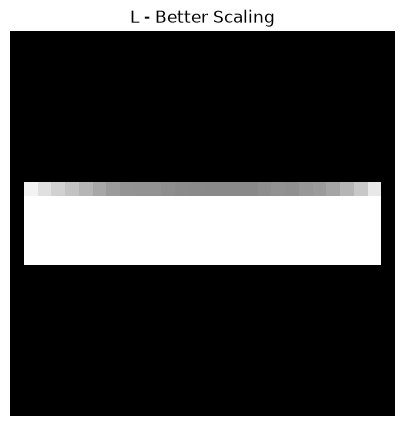

In [88]:
plt.figure(figsize=(5, 5))

plt.imshow(
    canvas_l,
    cmap="gray"
)

plt.title("L - Better Scaling")
plt.axis("off")

plt.show()

In [89]:
l_input = canvas_l.astype("float32") / 255.0

l_input = l_input.reshape(
    1,
    28,
    28,
    1
)

print("Input shape:", l_input.shape)
print("Min:", l_input.min())
print("Max:", l_input.max())

Input shape: (1, 28, 28, 1)
Min: 0.0
Max: 1.0


In [90]:
prediction = cnn.predict(
    l_input,
    verbose=0
)[0]

top5_indices = np.argsort(
    prediction
)[-5:][::-1]

print("===== L BETTER SCALING PREDICTION =====")

for idx in top5_indices:

    print(
        "Class:", int(idx),
        "| Character:", class_mapping[str(int(idx))],
        "| Confidence:",
        round(float(prediction[idx]) * 100, 2),
        "%"
    )

===== L BETTER SCALING PREDICTION =====
Class: 46 | Character: t | Confidence: 78.07 %
Class: 39 | Character: e | Confidence: 5.86 %
Class: 40 | Character: f | Confidence: 5.11 %
Class: 45 | Character: r | Confidence: 4.3 %
Class: 29 | Character: T | Confidence: 2.7 %


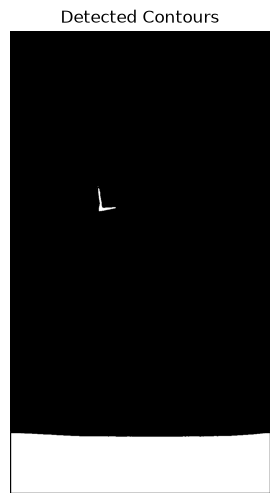

In [91]:
plt.figure(figsize=(10, 6))

plt.imshow(binary, cmap="gray")

for i, contour in enumerate(contours):

    x, y, w, h = cv2.boundingRect(contour)

    if w >= 5 and h >= 5:

        rectangle = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False
        )

        plt.gca().add_patch(rectangle)

        plt.text(
            x,
            y,
            str(i),
            fontsize=12
        )

plt.title("Detected Contours")
plt.axis("off")

plt.show()

In [92]:
print("===== CONTOURS =====")

for i, contour in enumerate(contours):

    x, y, w, h = cv2.boundingRect(contour)
    area = cv2.contourArea(contour)

    if w >= 5 and h >= 5:

        print(
            "Contour:", i,
            "| x:", x,
            "| y:", y,
            "| width:", w,
            "| height:", h,
            "| area:", round(area, 2)
        )

===== CONTOURS =====
Contour: 0 | x: 0 | y: 1111 | width: 720 | height: 169 | area: 113662.0
Contour: 1 | x: 241 | y: 431 | width: 53 | height: 69 | area: 514.5


In [1]:
import os

os.makedirs("../models", exist_ok=True)

cnn.save("../models/mnist_cnn.keras")

print("Saved:", os.path.abspath("../models/mnist_cnn.keras"))
print("Exists:", os.path.exists("../models/mnist_cnn.keras"))

NameError: name 'cnn' is not defined